# ***PA - Part II: Advanced Vision Models [Experiments with CIFAR10]*** (45pt)

**Keywords**: Multiclass Image Classification, ResNet, Vision Transformers, CLIP

**CIFAR10**
* The [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) database is a large database with images of objects like airplane, bird, cat, dog, etc.
* It contains 70,000 labeled images. Each datapoint is a $32\times 32$ pixels RGB image.
* To provide a realistic problem, we will use the images at this standard resolution of $32\times 32$.

**Agenda**:
* The PA is split into three parts, the first part dealing with miniature models which we will build from scratch, the second part dealing with modern architectures and the bonus third part dealing with training vision models robust to adversarial attacks.
* In this part, we will be moving towards more modern architectures and a more realistic problem, finetuning pretained model of different architectures on the CIFAR10 dataset and comparing its performance with models trained from scratch (initialized with random weights).
* We will also be evaluating CLIP, which uses an architecture which is a backbone or helper model in most modern LLMs for image analysis and even in image generation models.
* We will be using PyTorch and HuggingFace for loading and reusing complex model architecture.

**Note:**
* Hardware acceleration (GPU) is **highly recommended** for this part as we will be training comparitively larger models!
* If you are running locally, increase the `num_workers` parameter in the dataloaders to speed up computations. As Colab vCPUs have limits, it tends to be slower.
* A note on working with GPU:
  * Take care that whenever declaring new tensors, set `device=device` in parameters.
  * You can also move a declared torch tensor/model to device using `.to(device)`.
  * To move a torch model/tensor to cpu, use `.to('cpu')`
  * Keep in mind that all the tensors/model involved in a computation have to be on the same device (CPU/GPU).
* Run all the cells in order.
* Only **add your code** to cells marked with "TODO:" or with "..."
* You should not have to change variable names where provided, but you are free to if required for your implementation.



---



### **Pre-training and fine-tuning**

* In this part, we want to use modern architectures, namely the **ResNet** and **Vision Transformer**, for classification on the CIFAR10 dataset.
* Instead of trying to train these modern architectures from random weights for our task, we can instead use **pre-trained** models that have already been trained on a large amount of data.
* We can then **fine-tune** these models for our specific tasks.
* ImageNet is one such large-scale dataset (~1.3 million images) that is widely used for pretraining neural network models.
* These pretrained models serve as good initializations for various image-related tasks.
* We compare fine-tuned models and models trained from random initialization to analyze the difference in performance of these approaches.

### ***Setup: Imports and Utils***

In [1]:
!pip install open_clip_torch

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 20.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 36.1 MB/s  0:00:00

   ---------------------------------------- 0/3 [ftfy]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm]
   ------------- -------------------------- 1/3 [timm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip




---



cuda


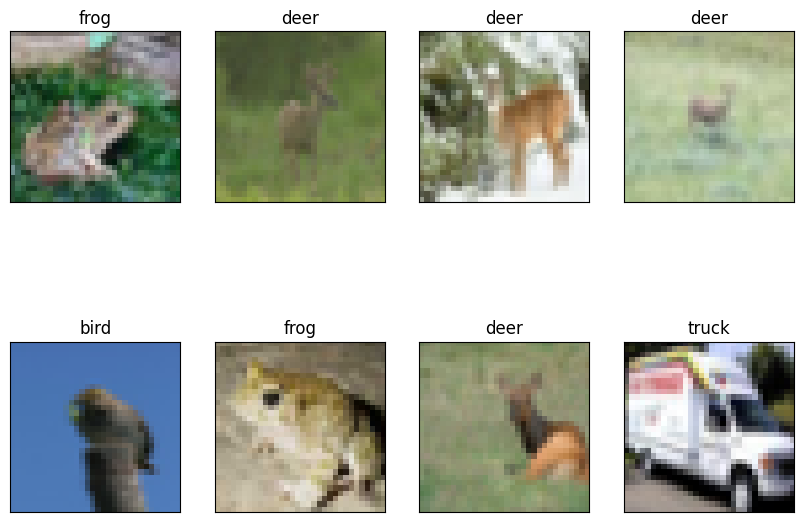

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import transformers
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
import timm
import math

batch_size = 100

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=4)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=4)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def unnormalize(img, mean, std):
    return img.mul_(std.reshape(-1, 1, 1)).add_(mean.reshape(-1, 1, 1))

# utility function to plot gallery of images
def plot_gallery(images, titles, height, width, n_row=2, n_col=4):
    plt.figure(figsize=(2* n_col, 3 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        curr_img = images[i]
        curr_img = unnormalize(curr_img, mean=torch.Tensor([0.485, 0.456, 0.406]), std=torch.Tensor([0.229, 0.224, 0.225]))
        plt.imshow(np.transpose(curr_img, (1, 2, 0)))
        plt.title(classes[titles[i]], size=12)
        plt.xticks(())
        plt.yticks(())


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# visualize some of the images of the CIFAR10 dataset
plot_gallery(images[:8], labels[:8], 32, 32, 2, 4)

### *(a) Training framework for CIFAR10* (10pt)

* For the more challenging CIFAR10 dataset, it is more useful to track the training and testing set accuracies during training.
* However, unlike with MNIST and the simple linear models, it is not always possible to load the entire dataset and pass the full batch through the model to compute the accuracy.
* Hence, we need to compute the accuracy in a mini-batch manner in the function `get_accuracy_cifar10`.
    * It takes as input the `model`, a `dataloader` (either for training or test set), and the `batch_size`.
* Following this, implement the training function `train_torch_model_cifar10` (similar to MNIST) but compute and print the training and testing accuracy after every epoch.
    * It should take as input the `model`, `trainloader`, `testloader`, `batch_size`, a predefined `optimizer`, the loss function `criterion`, maximum number of epochs `max_epochs`, and `tolerance`.
* You should be able to use the `train_torch_model` code from Part I by adding support for dataloaders.

In [4]:
def get_accuracy_cifar10(model, dataloader, batch_size):
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    acc = 100 * correct / total
    return acc

# Define a function train_torch_model_cifar10
def train_torch_model_cifar10(model, trainloader, testloader, batch_size, optimizer, criterion, max_epochs, tolerance, device='cuda'):
  losses = []
  train_acc = []
  test_acc = []
  prev_loss = float('inf')

  #######
  # 3. move model to device
  model.to(device)

  for epoch in tqdm(range(max_epochs)):
    for idx, (X_train_batch, y_train_batch) in enumerate(trainloader):
      # 3. move mini-batch data to device
      X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)

      # 4. reset gradients
      optimizer.zero_grad()

      # 5. prediction on mini-batch data
      pred = model(X_train_batch)

      # 6. calculate loss
      loss = criterion(pred, y_train_batch)

      # 7. backpropagate loss
      loss.backward()

      # 8. perform a single gradient update step
      optimizer.step()

    train_acc_curr = get_accuracy_cifar10(model, trainloader, batch_size)
    test_acc_curr = get_accuracy_cifar10(model, testloader, batch_size)
    #######
    # log loss every 100th epoch and print every 5000th epoch:
    losses.append((epoch, loss.item()))
    print('Epoch: {}, Loss: {}'.format(epoch, loss.item()))

    print("Train accuracy:", train_acc_curr)
    print("Test accuracy:", test_acc_curr)
    train_acc.append((epoch, train_acc_curr))
    test_acc.append((epoch, test_acc_curr))

    # break if decrease in loss is less than threshold
    if epoch > 0:
        loss_diff = prev_loss - loss.item()
        if loss_diff < tolerance:
            print(f"Early stopping at epoch {epoch}")
            break
    prev_loss = loss.item()

  # return updated model and logged losses
  return model, losses, train_acc, test_acc

### *(b) ResNet* (10pt)

#### #1. Training with random initialization

* Using the defined `train_torch_model_cifar10`, we will first train a model using the ResNet50 architecture from scratch.
* Hyperparameters:
  * Batch size of $100$
  * SGD optimizer with learning rate $0.001$ and momentum $0.9$
  * CE Loss
  * Train the model for a maximum of $15$ epochs.
* Use the `torchvision.models.resnet50` function to define the model and set the arguments such that pretrained weights are not used.
* The default `resnet50` model has 1000 output neurons (since ImageNet1k has 1000 classes) in the last layer while we need only 10 for CIFAR10.

We will also compute the training and testing set accuracies after every epoch and plot them.

In [7]:
from torchvision import models

model = models.resnet50(weights=None, num_classes=10)

batch_size = 100
# define optimizer (use torch.optim.SGD (Stochastic Gradient Descent))
# Set learning rate to lr and also set model parameters
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

model, losses, train_accs, test_accs = train_torch_model_cifar10(model, trainloader, testloader, batch_size, optimizer, torch.nn.CrossEntropyLoss(), max_epochs=15, tolerance=1e-6, device=device)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 0, Loss: 2.0099480152130127
Train accuracy: 35.958
Test accuracy: 34.09
Epoch: 1, Loss: 1.700219750404358
Train accuracy: 43.702
Test accuracy: 41.24
Epoch: 2, Loss: 1.376173973083496
Train accuracy: 49.478
Test accuracy: 44.89
Epoch: 3, Loss: 1.4372773170471191
Train accuracy: 53.84
Test accuracy: 47.65
Early stopping at epoch 3


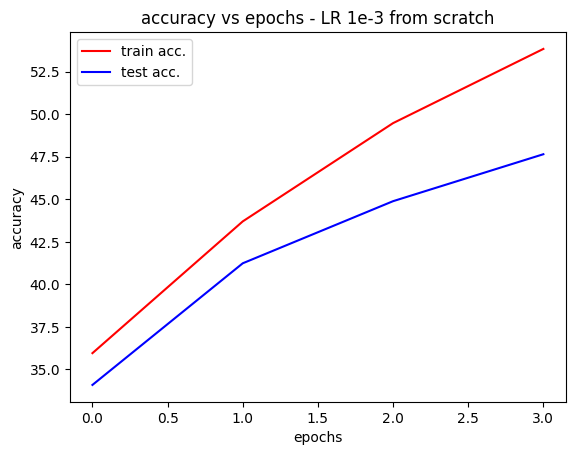

In [8]:
plt.plot([x[0] for x in train_accs],[x[1] for x in train_accs], 'r', label='train acc.')
plt.plot([x[0] for x in test_accs],[x[1] for x in test_accs], 'b', label='test acc.')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('accuracy vs epochs - LR 1e-3 from scratch')
plt.legend()
plt.show()

#### #2. Training with pretrained initialization

* Using the defined `train_torch_model_cifar10`, we will now train a ResNet50 model initialized from an ImageNet pretrained model.
* We will use the same hyperparameters as the previous part #2.1.
  * Batch size of $100$
  * SGD optimizer with learning rate $0.001$ and momentum $0.9$
  * CE Loss
  * Train the model for a maximum of $15$ epochs.
* We will use the same `torchvision.models.resnet50` function to define the model, but set the arguments such that ImageNet1k-v2 pretrained weights are used for initialization.

We will also compute and plot the training and testing set accuracies after every epoch.

In [29]:
model = models.resnet50(weights='IMAGENET1K_V2')
model.fc = torch.nn.Linear(model.fc.in_features, 10)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

model, losses, train_accs, test_accs = train_torch_model_cifar10(model, trainloader, testloader, batch_size, optimizer, torch.nn.CrossEntropyLoss(), max_epochs=15, tolerance=1e-6, device=device)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 0, Loss: 0.940744161605835
Train accuracy: 68.804
Test accuracy: 65.84
Epoch: 1, Loss: 0.751758337020874
Train accuracy: 80.068
Test accuracy: 74.75
Epoch: 2, Loss: 0.5851027965545654
Train accuracy: 85.336
Test accuracy: 77.24
Epoch: 3, Loss: 0.5739855766296387
Train accuracy: 88.936
Test accuracy: 78.34
Epoch: 4, Loss: 0.262912780046463
Train accuracy: 91.87
Test accuracy: 80.15
Epoch: 5, Loss: 0.23424674570560455
Train accuracy: 93.714
Test accuracy: 80.52
Epoch: 6, Loss: 0.2616279125213623
Train accuracy: 95.498
Test accuracy: 80.89
Early stopping at epoch 6


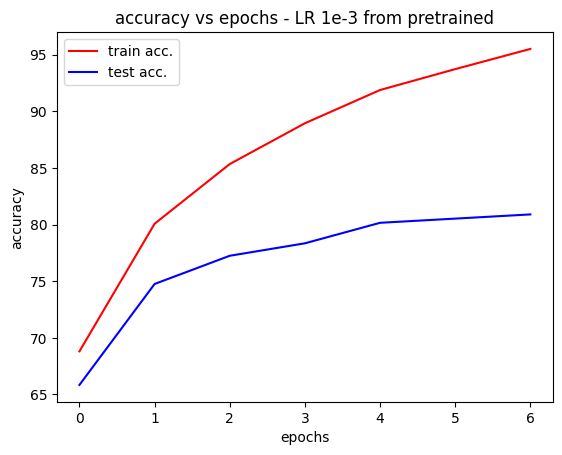

In [30]:
plt.plot([x[0] for x in train_accs],[x[1] for x in train_accs], 'r', label='train acc.')
plt.plot([x[0] for x in test_accs],[x[1] for x in test_accs], 'b', label='test acc.')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('accuracy vs epochs - LR 1e-3 from pretrained')
plt.legend()
plt.show()

### *(c) Vision Transformer* (https://arxiv.org/abs/2010.11929) (10pt)


* This architecture was proposed following the popularization of transformer models for language modeling.
* Vision Transformers can be considered a variation of transformers with image inputs.
* The images are divided as 16x16 patches (the size varies with different models) and a sequence of these patches is passed as the input to the transformer model.


First, we modify the shape of the images to be 224x224 as this is what the ViT model we are using expects.

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


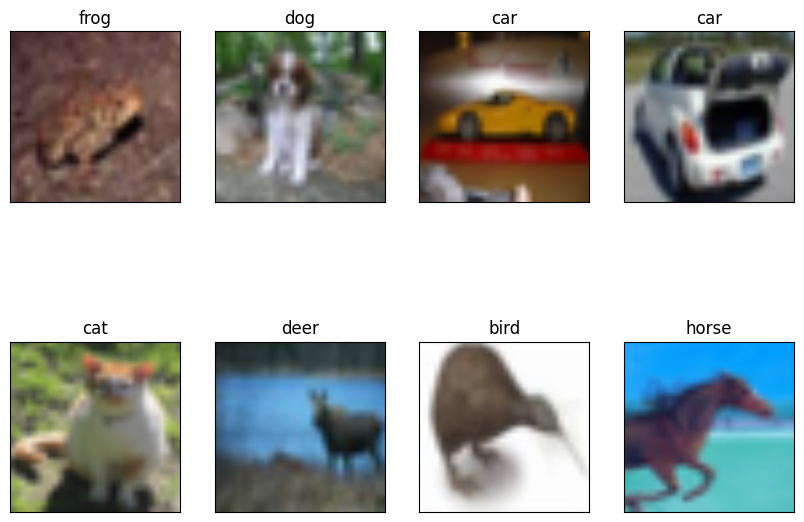

In [14]:
vit_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

vit_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=vit_transform)

vit_trainloader = torch.utils.data.DataLoader(vit_trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

vit_testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=vit_transform)
vit_testloader = torch.utils.data.DataLoader(vit_testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

dataiter = iter(vit_trainloader)
vit_images, vit_labels = next(dataiter)

# visualize some of the images of the CIFAR10 dataset
plot_gallery(vit_images[:8], vit_labels[:8], 32, 32, 2, 4)

#### #1. Training with random initialization

* Similarly, now we will use the `train_torch_model_cifar10` function to train a Classifier using the Vision Transformer Architecture
* Hyperparameters:
  * Batch size of $100$
  * SGD optimizer with learning rate $0.001$ and momentum $0.9$
  * CE Loss
  * Train the model for a maximum of $7$ epochs as training this model is slower than ResNet50.
* Use the `timm/efficientvit_m1.r224_in1k` model either using the `timm` library. We choose this model due to its small number of parameters (3M) which make it easy to train and experiment with.
* By setting the `num_classes` argument, we can customise the number of required classes which is 10, in the case of CIFAR10.



We will also compute the training and testing set accuracies after every epoch and plot them.

Note: This function may take approx 15 minutes to run. Ensure it works on a non-GPU runtime first to ensure you don't exhaust resources.

In [19]:
import torch.nn as nn
import timm

model = timm.create_model('efficientvit_m1.r224_in1k', pretrained=False, num_classes=10)

model, losses, train_accs, test_accs = train_torch_model_cifar10(model, vit_trainloader, vit_testloader, batch_size, optimizer, torch.nn.CrossEntropyLoss(), max_epochs=7, tolerance=1e-6, device=device)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 0, Loss: 2.371126651763916
Train accuracy: 9.532
Test accuracy: 9.35
Epoch: 1, Loss: 2.341001510620117
Train accuracy: 9.314
Test accuracy: 9.35
Epoch: 2, Loss: 2.322421073913574
Train accuracy: 9.468
Test accuracy: 9.35
Epoch: 3, Loss: 2.3620872497558594
Train accuracy: 9.36
Test accuracy: 9.35
Early stopping at epoch 3


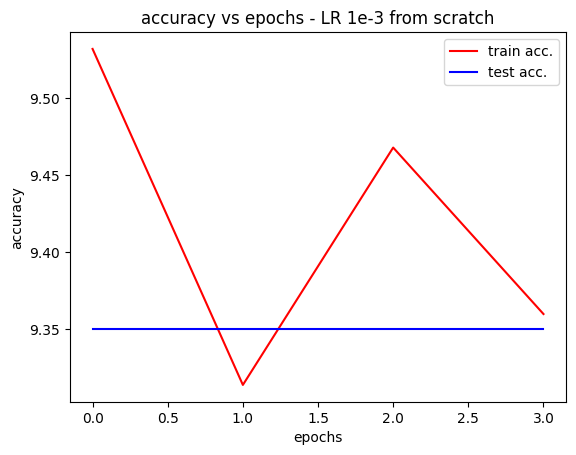

In [20]:
plt.plot([x[0] for x in train_accs],[x[1] for x in train_accs], 'r', label='train acc.')
plt.plot([x[0] for x in test_accs],[x[1] for x in test_accs], 'b', label='test acc.')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('accuracy vs epochs - LR 1e-3 from scratch')
plt.legend()
plt.show()

#### #2. Training with pretrained initialization


* We will use the same `timm/efficientvit_m1.r224_in1k` model but we will use its pretrained weights on ImageNet using the `pretained` parameter.
* We will use the same hyperparameters as the previous part #3.1.
  * Batch size of $100$
  * SGD optimizer with learning rate $0.001$ and momentum $0.9$
  * CE Loss
  * Train the model for a maximum of $7$ epochs.

We will also compute and plot the training and testing set accuracies after every epoch.

Note: This function may take approx 15 minutes to run. Ensure it works on a non-GPU runtime first to ensure you don't exhaust resources.

In [15]:
import torch.nn as nn
import timm

model = timm.create_model('efficientvit_m1.r224_in1k', pretrained=True, num_classes=10)
# define optimizer (use torch.optim.SGD (Stochastic Gradient Descent))
# Set learning rate to lr and also set model parameters
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

model, losses, train_accs, test_accs = train_torch_model_cifar10(model, vit_trainloader, vit_testloader, batch_size, optimizer, torch.nn.CrossEntropyLoss(), max_epochs=7, tolerance=1e-6, device=device)

model.safetensors:   0%|          | 0.00/12.1M [00:00<?, ?B/s]

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\TangyKiwi\.cache\huggingface\hub\models--timm--efficientvit_m1.r224_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 0, Loss: 1.1742831468582153
Train accuracy: 66.484
Test accuracy: 65.98
Epoch: 1, Loss: 0.720608651638031
Train accuracy: 79.286
Test accuracy: 78.78
Epoch: 2, Loss: 0.45442187786102295
Train accuracy: 85.456
Test accuracy: 84.78
Epoch: 3, Loss: 0.3313128650188446
Train accuracy: 88.238
Test accuracy: 86.84
Epoch: 4, Loss: 0.24218089878559113
Train accuracy: 89.204
Test accuracy: 87.88
Epoch: 5, Loss: 0.25919994711875916
Train accuracy: 91.018
Test accuracy: 89.01
Early stopping at epoch 5


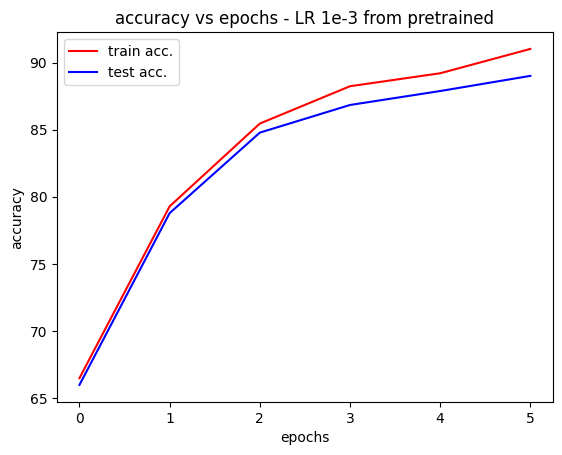

In [18]:
plt.plot([x[0] for x in train_accs],[x[1] for x in train_accs], 'r', label='train acc.')
plt.plot([x[0] for x in test_accs],[x[1] for x in test_accs], 'b', label='test acc.')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('accuracy vs epochs - LR 1e-3 from pretrained')
plt.legend()
plt.show()

### *(d) CLIP (Contrastive Language-Image Pretraining - [Paper](https://arxiv.org/abs/2103.00020) )* (10pt)

* CLIP jointly trains a text-encoder and image-encoder on images and text captions.
* CLIP generates representations (vector embeddings) of both the text and image such that they lie in the same vector space.
* CLIP optimizes the embeddings such that the image and captions are closer in the vector space if they correspond to each other and farther if they do not.
* The image-encoder is a pluggable model - usually a ResNet or Vision Transformer. We will use both.
* For this section, we will not be doing any pretraining or finetuning, rather just loading and evaluating it on CIFAR10 test-set (zero-shot image classification).

Note: This is a simplified explanation. You can read the paper if you need more details. However, this is not essential for the assignment.

In [21]:
import open_clip

captions = [f"a photo of a {label}" for label in classes]

clip_testset = torchvision.datasets.CIFAR10(root='./data', download=True, train=False)

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Note: We will use the `open_clip` package to run CLIP. You can refer the documentation at https://github.com/mlfoundations/open_clip

We define a new testset for CLIP since it uses PIL images as inputs and does not require tensor conversion

Note: We convert the class labels to a caption format which works better with CLIP.

#### #1. Predict and accuracy function

* Write the `clip_predict` function that takes in the CLIP `model`, a list of processed `images`, tokenized `texts` and encodes the texts and images.
* The function should then use the encoded features to find and return the predicted label for each of the `images`.

* Complete the `clip_accuracy` function takes in the CLIP `model`, the CLIP image `processor` and text/caption `tokenizer` and torchvision image `dataset` as input
* The function processes the images and texts into vectors in batch-form and uses the `clip_predict` predictions to calculate accuracy over the `dataset`

In [22]:
def clip_predict(model, images, texts):

  with torch.no_grad():
      # get the image and text vectors using the model's encode functions
      image_vectors = model.encode_image(images)
      text_vectors = model.encode_text(texts)

      # normalize the image and text vectors
      image_vectors = image_vectors / image_vectors.norm(dim=-1, keepdim=True)
      text_vectors = text_vectors / text_vectors.norm(dim=-1, keepdim=True) 

      # find the cosine similarity between the image and text vectors and softmax them to get the probabilities
      logits = model.logit_scale.exp() * image_vectors @ text_vectors.t()
      probs = logits.softmax(dim=-1)

      # calculate predicted label index
      preds = probs.argmax(dim=-1)

  #return predicted labels
  return preds

def clip_accuracy(model, processor, tokenizer, dataset, batch_size, captions=captions):

  # process the text using the tokenizer
  texts = tokenizer(captions).to(device)

  #calculate the number of batches
  number_of_batches = math.ceil(len(dataset) / batch_size)

  correct = 0

  for i in range(number_of_batches):

    # define start and end indices
    start = i * batch_size
    end = min((i + 1) * batch_size, len(dataset))

    # process the images in the batch using the processor
    images = torch.stack([processor(dataset[j][0]) for j in range(start, end)]).to(device)

    # get the labels
    labels = torch.tensor([dataset[j][1] for j in range(start, end)]).to(device)

    # use the clip_predict function to
    preds = clip_predict(model, images, texts)
    correct = correct + (preds == labels).sum().item()

  return correct / len(dataset)

#### #2. CLIP Model using Vision Transformer

* Use the `open_clip.create_model_and_transforms` function from the `open_clip` library to load the model and image processor.
* Pass the `ViT-B-32` as the model and `openai` as the pretrained weights to use.
* Use the `open_clip.get_tokenizer` with the same model name to get the tokenizer.

In [25]:
model,_, processor = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model.to(device)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


* Call the `clip_accuracy` function with appropriate parameters. Optionally, you can pass in custom images and captions to the `clip_predict` function to see interesting outputs.

In [26]:
clip_accuracy(model, processor, tokenizer, clip_testset, batch_size, captions)

0.8648

#### #3. CLIP Model using Resnet50

* We are now going to use a ResNet50 based CLIP-model instead of Vision Transformer a
* Use the same code as in #2 except the model name should be `RN50`

In [27]:
model,_, processor = open_clip.create_model_and_transforms('RN50', pretrained='openai')
model.to(device)
tokenizer = open_clip.get_tokenizer('RN50')

open_clip_model.safetensors:   0%|          | 0.00/408M [00:00<?, ?B/s]

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\TangyKiwi\.cache\huggingface\hub\models--timm--resnet50_clip.openai. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\ope

* Call the `clip_accuracy` function with appropriate parameters here. Optionally, you can pass in custom images and captions to the `clip_predict` function to see interesting outputs.

In [28]:
clip_accuracy(model, processor, tokenizer, clip_testset, batch_size, captions)

0.353

### *(e) Analysis* (5pt)

**Effect of pretraining**:  
ResNet50 random initialization resulted in a final train accuracy of 53.84 and
test accuracy of 47.65. Using the IMAGENET1K_V2 pretrained weights resulted in
a final train accuracy of 95.498 and test accuracy of 80.89. This is a significant
improvement. The vision transformer model with no pretraining resulted in a final
train accuracy of 9.36 and test accuracy of 9.35. This is actually worse than
random guessing the 10 classes. But with pretrainig, the final train accuracy
was 91.018 and final test accuracy was 89.01. This shows that pretraining is critical
for performance in ViT's, which makes sense as they don't have built in inductive
biases like locality in the ResNet. 

**Effect of architecture**:  
The ViT model performed the best. The ResNet50 model learns local spacial features
and works well for the small datset of CIFAR-10, and provides a good baseline
benchmark model. ViT on the other hand, learns global relationships via attention
and is able to capture complex patterns, but requires pretraining to work properly. 
This could also be the reason behind why it performs the best. The CLIP models 
enable zero-shot classification but its performance depends heavily on the backbone,
hence why the ViT CLIP model performs significantly better than the ResNet50 CLIP
model. Transformer-based models and multimodal models achieve superior performance 
when pretrained on large datasets, while CNNs remain more robust in low-data settings.